# 05 - Visualizing Performance Differences

Statistical tests like the Paired T-Test, Sign Test, and Wilcoxon Signed-Rank Test all rely on the *differences* in performance between two models across multiple datasets. 

Instead of just looking at p-values, it is incredibly helpful to **visualize** these differences. This allows you to instantly see:

1. Is the distribution of differences normal (symmetric around a mean)?
2. Are there extreme outliers?
3. Is one model consistently outperforming the other, or is the performance highly variable?

In `labicompare`, the `plot_difference_distribution` function provides a clear visualization of these pairwise differences.

In [1]:
import pandas as pd
import numpy as np
from labicompare.core.data import EvaluationData
from labicompare.plots.differences import plot_difference_distribution

# Let's reuse the data from our Pairwise Tests notebook
df = pd.read_csv("./results.csv", index_col="dataset")
eval_data = EvaluationData(df, higher_is_better=True)

print(eval_data)

<EvaluationData: 127 datasets, 8 models>


## Step 1: Visualizing a Distribution

Let's start by comparing `InceptionTime` and `FCN`. If we subtract the performance of B from A (`InceptionTime - FCN`), we can look at the spread of those values.

Because both models are stable, we expect their differences to be somewhat symmetric and clustered around a specific mean difference. This is the ideal scenario for a **Paired T-Test**.

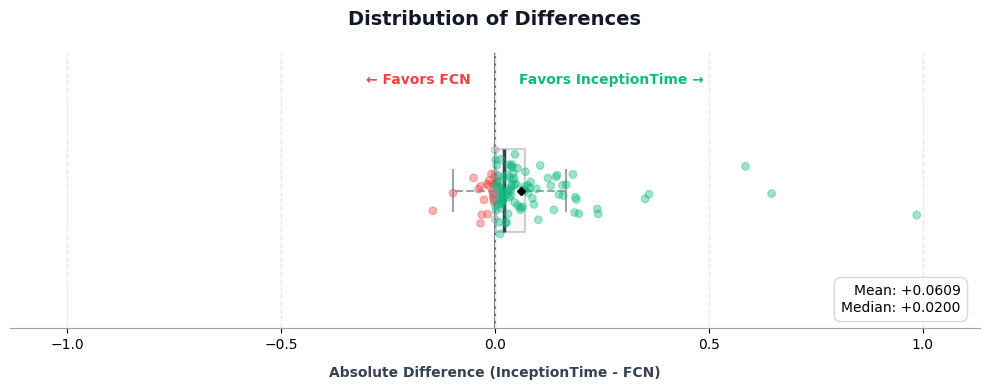

In [2]:
# Plot the distribution of differences between Model_A and Model_B
fig = plot_difference_distribution(
  data=eval_data,
  model_a='InceptionTime',
  model_b='FCN',
)

# If you are running this locally, fig.show() will render the plot.

**How to interpret this plot:**

* **Center (Mean):** The center of the distribution shows the average advantage one model has over the other. Since `InceptionTime` is generally better, the bulk of the distribution will be on the positive side.
* **Heavy Tails / Outliers:** You will notice that the distribution is no longer a neat bell curve. There are extreme values (where `FCN` scored 0.60 and 0.55) pulling the distribution into a long tail.
* **Statistical Impact:** Looking at this plot makes it obvious why the parametric Paired T-Test fails here. The mean is heavily distorted by those two terrible runs from `FCN`. This visual confirms why we should trust the **Wilcoxon Signed-Rank Test** (which uses robust ranking instead of raw means) for this specific pair.